In [1]:
# =========================================
# Robust Feature Extraction (post-augmentation)
# =========================================
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from pathlib import Path
import json
from tqdm import tqdm
import math

# -------------------------
# Config
# -------------------------
IMAGE_DIR = Path("augmented_dataset/images")   # directory with images (augmented or original)
METADATA_XLSX = Path("augmented_dataset/measurement_labels_with_feat_augmented.xlsx")
OUTPUT_DIR = Path("augmented_dataset/feature_cache")
FEATURES_CSV = OUTPUT_DIR / "extracted_features_augmented.csv"
MERGED_CSV = Path("augmented_dataset/modeling_ready_augmented.csv")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = OUTPUT_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# thresholds and params
VISIBILITY_TH = 0.4          # minimum average landmark visibility to consider "good"
MIN_KEYPOINTS = 10           # sanity min
BBOX_COVERAGE_TH = 0.12      # min fraction of image area that person bbox should occupy
BLUR_VAR_TH = 50.0           # below this value image is likely blurry
RANDOM_STATE = 42

TEST_SIZE = 0.15
VAL_SIZE = 0.15

# Target columns (adjust if different)
TARGET_COLS = ['SHOULDER_x', 'BUST_x', 'WAIST_x',
       'HIPS_x', 'HALF_LENGTH_x', 'FULL_LENGTH_x', 'SLEEVE_LENGTH_x']
ID_COL = 'USERID'
IMAGE_COL = 'IMAGES'

# MediaPipe setup
mp_pose = mp.solutions.pose
POSE = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.4, min_tracking_confidence=0.4)

# Landmark index mapping (we use the same mapping as earlier)
LM = {
    'nose': 0, 'left_eye_inner': 1, 'left_eye': 2, 'left_eye_outer': 3,
    'right_eye_inner': 4, 'right_eye': 5, 'right_eye_outer': 6, 'left_ear':7,'right_ear':8,
    'left_shoulder':11,'right_shoulder':12,'left_elbow':13,'right_elbow':14,'left_wrist':15,'right_wrist':16,
    'left_hip':23,'right_hip':24,'left_knee':25,'right_knee':26,'left_ankle':27,'right_ankle':28
}

# -------------------------
# Utilities
# -------------------------
def variance_of_laplacian_gray(image):
    """Return variance of Laplacian (blurriness measure). Assumes BGR input."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def bbox_from_landmarks(kps, img_w, img_h):
    """Compute bounding box from visible keypoints (x,y in pixels)."""
    coords = np.array([[p[0], p[1]] for p in kps if p is not None])
    if coords.size == 0:
        return None
    x_min, y_min = coords.min(axis=0)
    x_max, y_max = coords.max(axis=0)
    x_min = max(0, x_min); y_min = max(0, y_min)
    x_max = min(img_w, x_max); y_max = min(img_h, y_max)
    return (x_min, y_min, x_max, y_max)

def dist(a, b):
    return float(np.linalg.norm(np.array(a[:2]) - np.array(b[:2])))

# -------------------------
# Core: Extract landmarks for one image
# -------------------------
def extract_landmarks_for_image(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    h, w = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    res = POSE.process(img_rgb)
    if not res.pose_landmarks:
        return None
    kps = []
    for lm in res.pose_landmarks.landmark:
        kps.append([lm.x * w, lm.y * h, lm.z * w, lm.visibility])
    return {'kps': kps, 'img_h': h, 'img_w': w, 'image': img}

# -------------------------
# Core: Compute robust features from keypoints + image
# -------------------------
def compute_features_from_landmarks_and_image(kps, img_h, img_w, image):
    feats = {}
    if not kps:
        return None

    # get convenience indices with try/except
    try:
        ls = kps[LM['left_shoulder']]
        rs = kps[LM['right_shoulder']]
        lh = kps[LM['left_hip']]
        rh = kps[LM['right_hip']]
        lw = kps[LM['left_wrist']]
        rw = kps[LM['right_wrist']]
        la = kps[LM['left_ankle']]
        ra = kps[LM['right_ankle']]
    except Exception:
        # missing expected keypoints
        return None

    # compute per-landmark visibility mean (only use landmarks we care about)
    vis_list = [kp[3] for kp in [ls, rs, lh, rh, lw, rw, la, ra] if kp is not None]
    avg_visibility = float(np.mean(vis_list)) if len(vis_list) > 0 else 0.0
    feats['avg_visibility'] = avg_visibility

    # pixel distances
    shoulder_px = dist(ls, rs)
    hip_px = dist(lh, rh)
    sleeve_left_px = dist(ls, lw)
    sleeve_right_px = dist(rs, rw)
    sleeve_px = float((sleeve_left_px + sleeve_right_px) / 2.0)

    # torso length proxy (mid shoulder to mid hip)
    mid_shoulder = ((ls[0] + rs[0]) / 2.0, (ls[1] + rs[1]) / 2.0)
    mid_hip = ((lh[0] + rh[0]) / 2.0, (lh[1] + rh[1]) / 2.0)
    torso_px = dist((mid_shoulder[0], mid_shoulder[1]), (mid_hip[0], mid_hip[1]))

    # height proxy from mid-shoulder to lowest ankle
    lowest_ank_y = max(la[1], ra[1])
    height_px = float(abs(lowest_ank_y - mid_shoulder[1]) + 1e-6)

    # depth-like (z) features (average)
    shoulder_z = float((ls[2] + rs[2]) / 2.0)
    hip_z = float((lh[2] + rh[2]) / 2.0)

    # bounding box and coverage
    bbox = bbox_from_landmarks(kps, img_w, img_h)
    if bbox is None:
        bbox_area = 0.0
    else:
        x1, y1, x2, y2 = bbox
        bbox_area = max(0.0, (x2 - x1) * (y2 - y1))
    img_area = float(img_w * img_h)
    bbox_coverage = float(bbox_area / (img_area + 1e-9))

    # blurriness
    blur_var = float(variance_of_laplacian_gray(image))

    # Populate basic pixel features
    feats.update({
        'shoulder_px': float(shoulder_px),
        'hip_px': float(hip_px),
        'sleeve_px': float(sleeve_px),
        'torso_px': float(torso_px),
        'height_px': float(height_px),
        'shoulder_z': shoulder_z,
        'hip_z': hip_z,
        'bbox_coverage': bbox_coverage,
        'blur_var': blur_var
    })

    # Ratio and normalized features (scale-invariant)
    feats['shoulder_to_hip_ratio'] = float(shoulder_px / (hip_px + 1e-6))
    feats['shoulder_to_height_ratio'] = float(shoulder_px / (height_px + 1e-6))
    feats['hip_to_height_ratio'] = float(hip_px / (height_px + 1e-6))
    feats['sleeve_to_height_ratio'] = float(sleeve_px / (height_px + 1e-6))
    feats['sleeve_to_shoulder_ratio'] = float(sleeve_px / (shoulder_px + 1e-6))
    feats['torso_to_height_ratio'] = float(torso_px / (height_px + 1e-6))
    feats['torso_to_shoulder_ratio'] = float(torso_px / (shoulder_px + 1e-6))

    # quality flags (useful later to filter or weight)
    feats['low_visibility_flag'] = int(avg_visibility < VISIBILITY_TH)
    feats['low_coverage_flag'] = int(bbox_coverage < BBOX_COVERAGE_TH)
    feats['blurry_flag'] = int(blur_var < BLUR_VAR_TH)

    return feats

# -------------------------
# Main loop: iterate metadata and compute/cache features
# -------------------------
meta = pd.read_excel(METADATA_XLSX)
print("Loaded metadata rows:", len(meta))

rows = []
skipped = 0

for idx, r in tqdm(meta.iterrows(), total=len(meta), desc="Extracting / caching features"):
    img_file = r['IMAGES']
    img_path = IMAGE_DIR / img_file
    if not img_path.exists():
        skipped += 1
        # mark missing file
        continue

    cache_p = OUTPUT_DIR / f"feat_{Path(img_file).stem}.json"
    if cache_p.exists():
        try:
            data = json.load(open(cache_p, 'r'))
            feats = data.get('features')
        except Exception:
            feats = None
    else:
        lk = extract_landmarks_for_image(img_path)
        if lk is None or 'kps' not in lk:
            feats = None
        else:
            feats = compute_features_from_landmarks_and_image(lk['kps'], lk['img_h'], lk['img_w'], lk['image'])
        # cache even None to avoid repeated attempts
        with open(cache_p, 'w') as f:
            json.dump({'features': feats}, f, default=float)

    if feats is None:
        # keep a record of failure for auditing but don't crash
        skipped += 1
        continue

    # combine features with metadata row
    combined = r.to_dict()
    combined.update(feats)
    rows.append(combined)

print(f"Completed extraction. Processed: {len(rows)}, Skipped: {skipped}")

# -------------------------
# Save features CSV
# -------------------------
features_df = pd.DataFrame(rows)
features_df.to_csv(FEATURES_CSV, index=False)
print("Saved features CSV:", FEATURES_CSV)

# -------------------------
# Merge with labels (targets)
# -------------------------
# Make sure ID/IMAGE columns consistent
if 'IMAGES' not in features_df.columns:
    features_df['IMAGES'] = features_df['image_name'] if 'image_name' in features_df.columns else features_df.get('IMAGES', None)

common_cols = list(set(meta.columns).intersection(set(features_df.columns)))

merged = meta.merge(features_df, on=common_cols, how='inner')
# Better: merge on USERID and IMAGES if present
if {'USERID','IMAGES'}.issubset(set(meta.columns)) and {'USERID','IMAGES'}.issubset(set(features_df.columns)):
    merged = meta.merge(features_df, on=['USERID','IMAGES'], how='inner')

print("Merged dataset shape:", merged.shape)

# -------------------------
# Optional: Filter low-quality frames (flagged)
# -------------------------
# You can drop or keep but mark. Here we keep but create a 'quality' column
def quality_flag(row):
    flags = row.get('low_visibility_flag', 0) + row.get('low_coverage_flag',0) + row.get('blurry_flag',0)
    return 'low' if flags > 0 else 'ok'

merged['data_quality'] = merged.apply(quality_flag, axis=1)

# Save final CSV
merged.to_csv(MERGED_CSV, index=False)
print("Saved merged modeling-ready CSV:", MERGED_CSV)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Loaded metadata rows: 279


Extracting / caching features: 100%|█████████████████████| 279/279 [00:01<00:00, 149.27it/s]


Completed extraction. Processed: 176, Skipped: 103
Saved features CSV: augmented_dataset/feature_cache/extracted_features_augmented.csv
Merged dataset shape: (176, 40)
Saved merged modeling-ready CSV: augmented_dataset/modeling_ready_augmented.csv


In [2]:
meta.columns

Index(['USERID', 'IMAGES', 'GENDER', 'SHOULDER', 'BUST', 'WAIST', 'HIPS',
       'HALF_LENGTH', 'FULL_LENGTH', 'SLEEVE_LENGTH', 'AUGMENT_ID'],
      dtype='object')

Plotting feature distributions...


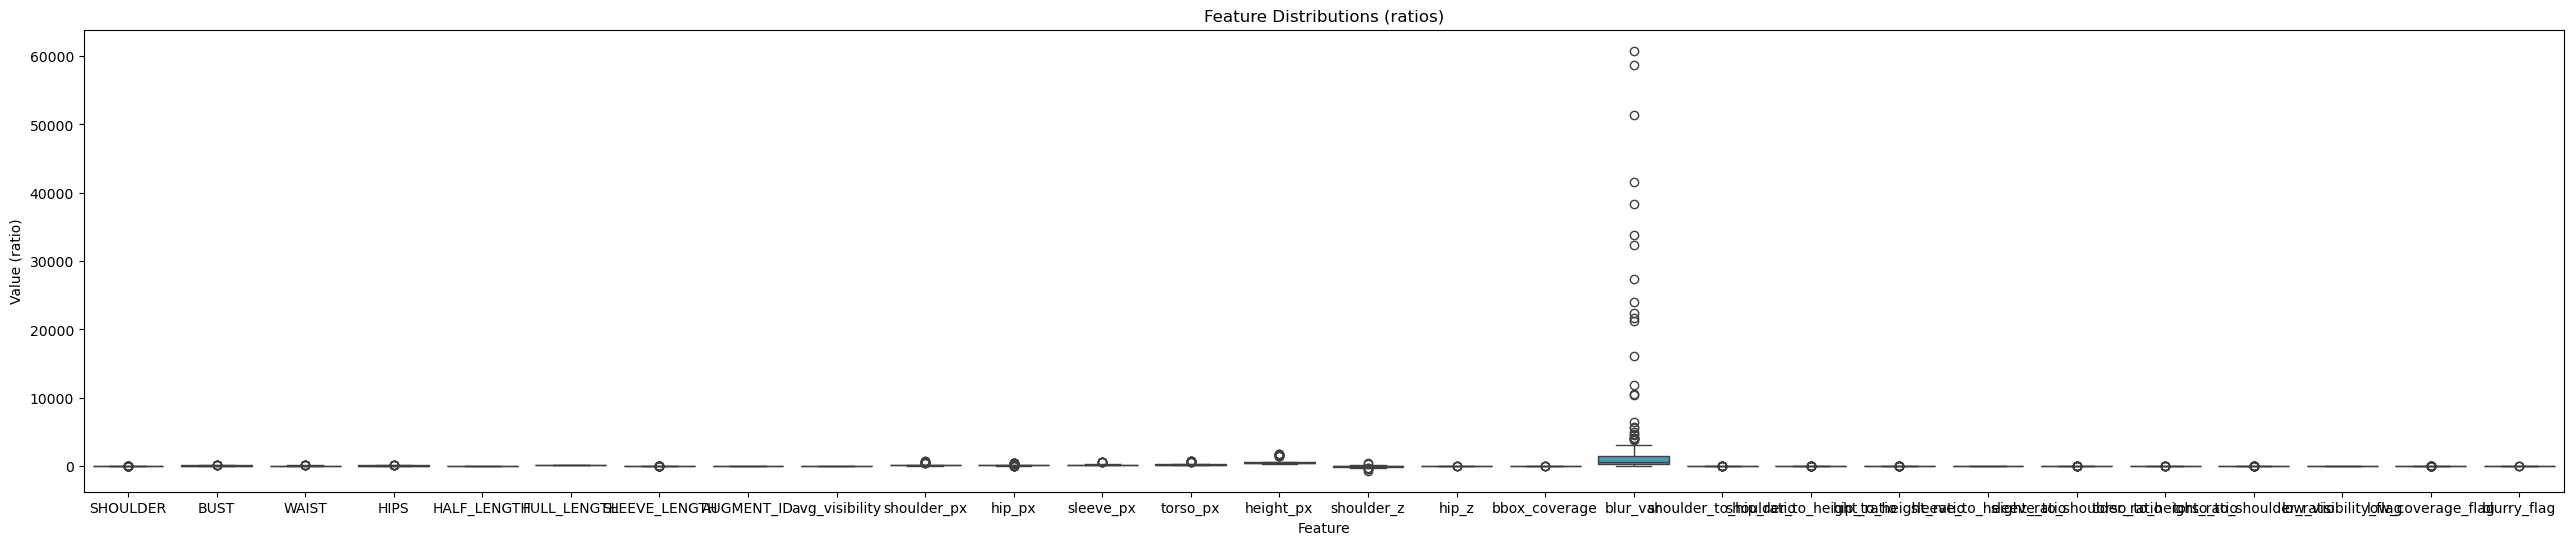

Pairplot skipped due to size or environment: name 'labels' is not defined


In [3]:
# 1) Plot feature distributions and pairwise relationships
import matplotlib.pyplot as plt
import seaborn as sns

print('Plotting feature distributions...')
plt.figure(figsize=(32,6))
sns.boxplot(data=features_df)
plt.title('Feature Distributions (ratios)')
plt.xlabel('Feature')
plt.ylabel('Value (ratio)')
plt.show()

# Pairwise scatter matrix (small figure)
try:
    sns.pairplot(features_df.sample(min(200, len(labels))), corner=True)
    plt.suptitle('Pairwise relationships (sample)')
    plt.show()
except Exception as e:
    print('Pairplot skipped due to size or environment:', e)

In [4]:
merged.columns

Index(['USERID', 'IMAGES', 'GENDER_x', 'SHOULDER_x', 'BUST_x', 'WAIST_x',
       'HIPS_x', 'HALF_LENGTH_x', 'FULL_LENGTH_x', 'SLEEVE_LENGTH_x',
       'AUGMENT_ID_x', 'GENDER_y', 'SHOULDER_y', 'BUST_y', 'WAIST_y', 'HIPS_y',
       'HALF_LENGTH_y', 'FULL_LENGTH_y', 'SLEEVE_LENGTH_y', 'AUGMENT_ID_y',
       'avg_visibility', 'shoulder_px', 'hip_px', 'sleeve_px', 'torso_px',
       'height_px', 'shoulder_z', 'hip_z', 'bbox_coverage', 'blur_var',
       'shoulder_to_hip_ratio', 'shoulder_to_height_ratio',
       'hip_to_height_ratio', 'sleeve_to_height_ratio',
       'sleeve_to_shoulder_ratio', 'torso_to_height_ratio',
       'torso_to_shoulder_ratio', 'low_visibility_flag', 'low_coverage_flag',
       'blurry_flag', 'data_quality'],
      dtype='object')

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import mlflow
import shap
import joblib

/home/samfash/anaconda3/envs/ml_env/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


In [6]:
# -------------------------
# 4. Train/Test/Val split (by USERID to avoid leakage between images of same person)
# -------------------------

# %%
if ID_COL in merged.columns:
    persons = merged[ID_COL].unique()
    train_persons, test_persons = train_test_split(persons, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    train_persons, val_persons = train_test_split(train_persons, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=RANDOM_STATE)
    train_df = merged[merged[ID_COL].isin(train_persons)].reset_index(drop=True)
    val_df = merged[merged[ID_COL].isin(val_persons)].reset_index(drop=True)
    test_df = merged[merged[ID_COL].isin(test_persons)].reset_index(drop=True)
else:
    train_val, test_df = train_test_split(merged, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    train_df, val_df = train_test_split(train_val, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=RANDOM_STATE)

print('Train/Val/Test sizes:', len(train_df), len(val_df), len(test_df))

# Feature columns we engineered
engineered_feats = ['avg_visibility', 'shoulder_px', 'hip_px', 'sleeve_px','shoulder_z', 'hip_z', 'bbox_coverage', 'blur_var',
       'shoulder_to_hip_ratio', 'shoulder_to_height_ratio',
       'hip_to_height_ratio', 'sleeve_to_height_ratio',
       'sleeve_to_shoulder_ratio', 'torso_to_height_ratio',
       'torso_to_shoulder_ratio']
feature_cols = [c for c in engineered_feats if c in merged.columns]
print('Using feature columns:', feature_cols)

Train/Val/Test sizes: 127 23 26
Using feature columns: ['avg_visibility', 'shoulder_px', 'hip_px', 'sleeve_px', 'shoulder_z', 'hip_z', 'bbox_coverage', 'blur_var', 'shoulder_to_hip_ratio', 'shoulder_to_height_ratio', 'hip_to_height_ratio', 'sleeve_to_height_ratio', 'sleeve_to_shoulder_ratio', 'torso_to_height_ratio', 'torso_to_shoulder_ratio']


In [7]:
engineered_feats = ['avg_visibility', 'shoulder_px', 'hip_px', 'sleeve_px',
                    'shoulder_z', 'hip_z', 'bbox_coverage', 'blur_var',
       'shoulder_to_hip_ratio', 'shoulder_to_height_ratio',
       'hip_to_height_ratio', 'sleeve_to_height_ratio',
       'sleeve_to_shoulder_ratio', 'torso_to_height_ratio',
       'torso_to_shoulder_ratio']

feature_cols = [c for c in engineered_feats if c in merged.columns]
print('Using feature columns:', feature_cols)

X_train = train_df[feature_cols].values
X_val = val_df[feature_cols].values
X_test = test_df[feature_cols].values

Y_train = train_df[TARGET_COLS].values
Y_val = val_df[TARGET_COLS].values
Y_test = test_df[TARGET_COLS].values

# Impute and scale
imp = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_train = imp.fit_transform(X_train)
X_val = imp.transform(X_val)
X_test = imp.transform(X_test)

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

joblib.dump(imp, MODELS_DIR / 'imputer.pkl')
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
joblib.dump(feature_cols, MODELS_DIR / 'feature_cols.pkl')

Using feature columns: ['avg_visibility', 'shoulder_px', 'hip_px', 'sleeve_px', 'shoulder_z', 'hip_z', 'bbox_coverage', 'blur_var', 'shoulder_to_hip_ratio', 'shoulder_to_height_ratio', 'hip_to_height_ratio', 'sleeve_to_height_ratio', 'sleeve_to_shoulder_ratio', 'torso_to_height_ratio', 'torso_to_shoulder_ratio']


['augmented_dataset/feature_cache/models/feature_cols.pkl']

In [8]:
# ==========================================================
# Utility: Dataset Version Tagging
# ==========================================================
import hashlib

def get_dataset_version_info(file_path):
    """
    Compute SHA256 hash of dataset to track version in MLflow.
    Returns a dict with version metadata.
    """
    file_path = Path(file_path)
    with open(file_path, "rb") as f:
        file_hash = hashlib.sha256(f.read()).hexdigest()
    size_kb = round(file_path.stat().st_size / 1024, 1)
    df = pd.read_excel(file_path) if file_path.suffix in ['.xlsx', '.xls'] else pd.read_csv(file_path)
    info = {
        "dataset_name": file_path.name,
        "dataset_rows": len(df),
        "dataset_hash": file_hash[:16],  # shortened for readability
        "dataset_size_kb": size_kb
    }
    return info

# ------------------------------
# MLflow lightweight helper
# ------------------------------
def log_experiment(
    model_name,
    params,
    X_train,
    Y_train,
    X_test,
    Y_test,
    Y_pred,
    feature_cols,
    target_cols,
    tag_note=None,
    dataset_info=None
):
    """Minimal local MLflow logger for dev experiments."""
    mlflow.set_experiment("BodyMeasurement_Dev")
    with mlflow.start_run(run_name=model_name):
        if tag_note:
            mlflow.set_tag("note", tag_note)

        # log params
        mlflow.log_param("model_name", model_name)
        for k, v in params.items():
            mlflow.log_param(k, v)

        # compute metrics
        maes, rmses = [], []
        for i, t in enumerate(target_cols):
            mae = mean_absolute_error(Y_test[:, i], Y_pred[:, i])
            mse = mean_squared_error(Y_test[:, i], Y_pred[:, i])
            rmse = np.sqrt(mse)
            maes.append(mae)
            rmses.append(rmse)
            mlflow.log_metric(f"MAE_{t}", mae)
            mlflow.log_metric(f"RMSE_{t}", rmse)

        avg_mae, avg_rmse = np.mean(maes), np.mean(rmses)
        mlflow.log_metric("avg_MAE_in", avg_mae)
        mlflow.log_metric("avg_RMSE_in", avg_rmse)

        # save summary CSV
        metrics_df = pd.DataFrame({
            "Target": target_cols,
            "MAE_in": maes,
            "RMSE_in": rmses
        })
        csv_path = Path("metrics_summary.csv")
        metrics_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(str(csv_path))
        csv_path.unlink()

        # sample visualization (Predicted vs True for first target)
        i = 0
        fig, ax = plt.subplots(figsize=(5,5))
        ax.scatter(Y_test[:, i], Y_pred[:, i], alpha=0.5, s=15, color='teal')
        lims = [min(Y_test[:, i].min(), Y_pred[:, i].min()), max(Y_test[:, i].max(), Y_pred[:, i].max())]
        ax.plot(lims, lims, 'k--', lw=1)
        ax.set_xlabel("True (in)")
        ax.set_ylabel("Predicted (in)")
        ax.set_title(f"{model_name}: {target_cols[i]} Predictions")
        fig.tight_layout()
        fig.savefig("pred_vs_true.png", dpi=120)
        mlflow.log_artifact("pred_vs_true.png")
        plt.close(fig)

        if dataset_info:
            mlflow.set_tag("dataset_name", dataset_info["dataset_name"])
            mlflow.set_tag("dataset_hash", dataset_info["dataset_hash"])
            mlflow.set_tag("dataset_rows", dataset_info["dataset_rows"])
            mlflow.set_tag("dataset_size_kb", dataset_info["dataset_size_kb"])

        print(f"✅ Logged {model_name} | avg_MAE={avg_mae:.3f}, avg_RMSE={avg_rmse:.3f}")
        mlflow.end_run()


# Utility: Average MAE across targets
def avg_mae(y_true, y_pred):
    return np.mean([mean_absolute_error(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])



In [9]:
# Define your dataset path
dataset_info = get_dataset_version_info(METADATA_XLSX)

In [10]:
# ========== XGBOOST ==========

xgb_models = {}
xgb_preds = np.zeros_like(Y_test)
for i, target in enumerate(TARGET_COLS):
    print(f"\n🧠 Training XGBoost for {target}")
    dtrain = xgb.DMatrix(X_train, label=Y_train[:, i])
    dval = xgb.DMatrix(X_val, label=Y_val[:, i])
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'eta': 0.15,
        'max_depth': 4,
        'subsample':  1.0,
        'colsample_bytree': 0.8,
        'seed': RANDOM_STATE
    }
    bst = xgb.train(params, dtrain, num_boost_round=333,
                    evals=[(dval, 'val')],
                    early_stopping_rounds=30,
                    verbose_eval=False)
    xgb_models[target] = bst
    bst.save_model(str(MODELS_DIR / f"xgb_{target}.json"))
    xgb_preds[:, i] = bst.predict(xgb.DMatrix(X_test))

joblib.dump(xgb_models, MODELS_DIR / "xgb_models.pkl")

# Log experiment for XGBoost
log_experiment(
    model_name="XGBoost_per_target",
    params={'eta': 0.15, 'max_depth': 4, 'rounds': 333,'subsample': 1.0,'colsample_bytree': 0.8},
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    Y_pred=xgb_preds,
    feature_cols=feature_cols,
    target_cols=TARGET_COLS,
    tag_note="Baseline XGBoost across 7 targetswith_torso",
    dataset_info=dataset_info
)
#============ xgb but xgbregressor ===========
print("\n🌲 Training Xgb Multi-Output Regressor...")
xgb_multi = MultiOutputRegressor(xgb.XGBRegressor(objective= 'reg:squarederror',
        eval_metric= 'mae',
        learning_rate= 0.05,
        max_depth= 4,
        subsample= 1.0,
        colsample_bytree= 0.8,
        n_estimators= 333,
        reg_lambda=  1.3187923518236957,
        reg_alpha= 0.4706120522769641,
        random_state= RANDOM_STATE
))
xgb_multi.fit(X_train, Y_train)
xgb_multi_preds = xgb_multi.predict(X_test)
joblib.dump(xgb_multi, MODELS_DIR / "xgb_multi.pkl")

# Log experiment for xgbregressor
log_experiment(
    model_name="Xgboost_MultiOutput",
    params={'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'eta': 0.05,
        'max_depth': 4},
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    Y_pred=xgb_multi_preds,
    feature_cols=feature_cols,
    target_cols=TARGET_COLS,
    tag_note="Baseline xgbboost_multi",
    dataset_info=dataset_info
)

# ========== RANDOM FOREST ==========
print("\n🌲 Training RandomForest Multi-Output Regressor...")
rf = MultiOutputRegressor(RandomForestRegressor(
    n_estimators=285,
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    n_jobs=-1,
    max_features='log2',
    random_state=RANDOM_STATE
))
rf.fit(X_train, Y_train)
rf_preds = rf.predict(X_test)
joblib.dump(rf, MODELS_DIR / "rf_multi.pkl")

# Log experiment for RandomForest
log_experiment(
    model_name="RandomForest_MultiOutput",
    params={'n_estimators':285,'max_depth':20,'min_samples_leaf':1},
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    Y_pred=rf_preds,
    feature_cols=feature_cols,
    target_cols=TARGET_COLS,
    tag_note="Baseline RandomForest v1_with torso",
    dataset_info=dataset_info
)


# ========== MLP ==========
print("\n⚡ Training MLP Multi-Output Regressor...")
mlp = MLPRegressor(hidden_layer_sizes=(256,128), max_iter=2000, random_state=RANDOM_STATE)
mlp_multi = MultiOutputRegressor(mlp)
mlp_multi.fit(X_train, Y_train)
mlp_preds = mlp_multi.predict(X_test)
joblib.dump(mlp_multi, MODELS_DIR / "mlp_multi.pkl")

# Log experiment for MLP
log_experiment(
    model_name="MLP_MultiOutput",
    params={'hidden_layers':'(256,128)','max_iter':2000},
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    Y_pred=mlp_preds,
    feature_cols=feature_cols,
    target_cols=TARGET_COLS,
    tag_note="Baseline MLP fully connected",
    dataset_info=dataset_info
)


🧠 Training XGBoost for SHOULDER_x

🧠 Training XGBoost for BUST_x

🧠 Training XGBoost for WAIST_x

🧠 Training XGBoost for HIPS_x

🧠 Training XGBoost for HALF_LENGTH_x

🧠 Training XGBoost for FULL_LENGTH_x

🧠 Training XGBoost for SLEEVE_LENGTH_x
✅ Logged XGBoost_per_target | avg_MAE=3.465, avg_RMSE=3.713

🌲 Training Xgb Multi-Output Regressor...
✅ Logged Xgboost_MultiOutput | avg_MAE=3.469, avg_RMSE=3.730

🌲 Training RandomForest Multi-Output Regressor...
✅ Logged RandomForest_MultiOutput | avg_MAE=3.697, avg_RMSE=3.921

⚡ Training MLP Multi-Output Regressor...


/home/samfash/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/samfash/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/samfash/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


✅ Logged MLP_MultiOutput | avg_MAE=4.793, avg_RMSE=5.660


In [11]:
# ----------------------------------------------------------
# EVALUATE ALL MODELS
# ----------------------------------------------------------
def evaluate_model(name, y_true, y_pred):
    mae = [mean_absolute_error(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    rmse = [np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])) for i in range(y_true.shape[1])]
    within_1 = [np.mean(np.abs(y_true[:, i] - y_pred[:, i]) <= 1) * 100 for i in range(y_true.shape[1])]
    df = pd.DataFrame({'Target': TARGET_COLS, 'MAE_in': mae, 'RMSE_in': rmse, 'Within_1inch_%': within_1})
    print(f"\n📊 {name} Performance Metrics")
    print(df.round(3))
    return df

xgb_metrics = evaluate_model("XGBoost", Y_test, xgb_preds)
xgb_multi_metrics = evaluate_model("XGB_multi", Y_test, xgb_multi_preds)
rf_metrics = evaluate_model("RandomForest", Y_test, rf_preds)
mlp_metrics = evaluate_model("MLP", Y_test, mlp_preds)

# ----------------------------------------------------------
# COMPARE & SELECT BEST
# ----------------------------------------------------------
xgb_mae = avg_mae(Y_test, xgb_preds)
xgb_multi_mae = avg_mae(Y_test, xgb_multi_preds)
rf_mae = avg_mae(Y_test, rf_preds)
mlp_mae = avg_mae(Y_test, mlp_preds)

print("\n🔍 Average MAE Comparison:")
print(f"XGBoost: {xgb_mae:.3f}| xgb_multi: {xgb_multi_mae:.3f} | RF: {rf_mae:.3f} | MLP: {mlp_mae:.3f}")

best_name = min(
    {'xgb': xgb_mae, 'rf': rf_mae, 'mlp': mlp_mae},
    key={'xgb': xgb_mae, 'rf': rf_mae, 'mlp': mlp_mae}.get
)
print(f"\n🏆 Best performing model: {best_name.upper()}")

# Save best model
if best_name == 'xgb':
    joblib.dump(xgb_models, MODELS_DIR / "best_models.pkl")
elif best_name == 'rf':
    joblib.dump(rf, MODELS_DIR / "best_models.pkl")
elif best_name == 'xgb_multi':
    joblib.dump(xgb_multi, MODELS_DIR / "best_models.pkl")
else:
    joblib.dump(mlp_multi, MODELS_DIR / "best_models.pkl")


📊 XGBoost Performance Metrics
            Target  MAE_in  RMSE_in  Within_1inch_%
0       SHOULDER_x   1.016    1.158          69.231
1           BUST_x   4.516    5.121           0.000
2          WAIST_x   4.296    4.412           0.000
3           HIPS_x   6.249    6.462           0.000
4    HALF_LENGTH_x   2.367    2.737           3.846
5    FULL_LENGTH_x   4.952    5.076           0.000
6  SLEEVE_LENGTH_x   0.858    1.025          61.538

📊 XGB_multi Performance Metrics
            Target  MAE_in  RMSE_in  Within_1inch_%
0       SHOULDER_x   1.159    1.315          38.462
1           BUST_x   4.594    5.154           0.000
2          WAIST_x   4.275    4.428           0.000
3           HIPS_x   6.322    6.585           0.000
4    HALF_LENGTH_x   2.153    2.581           7.692
5    FULL_LENGTH_x   4.869    4.984           0.000
6  SLEEVE_LENGTH_x   0.912    1.067          46.154

📊 RandomForest Performance Metrics
            Target  MAE_in  RMSE_in  Within_1inch_%
0       SHOULDER

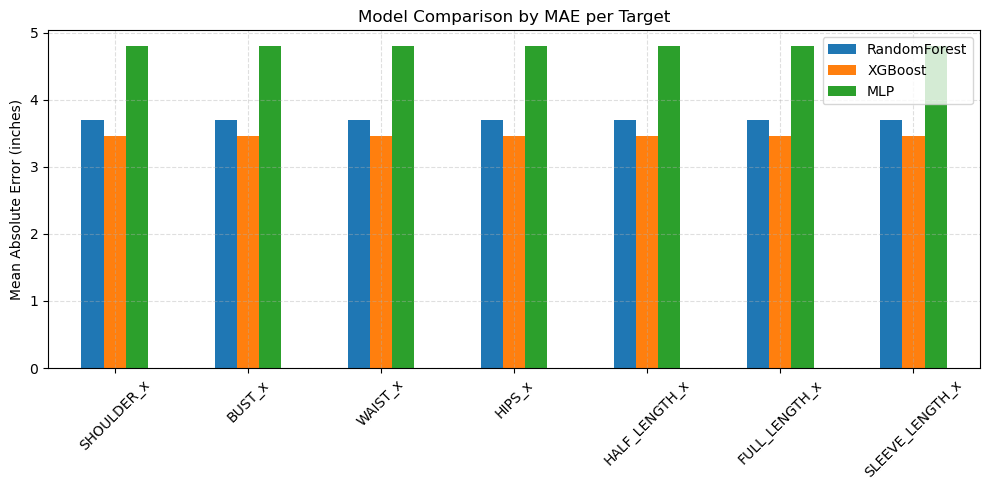

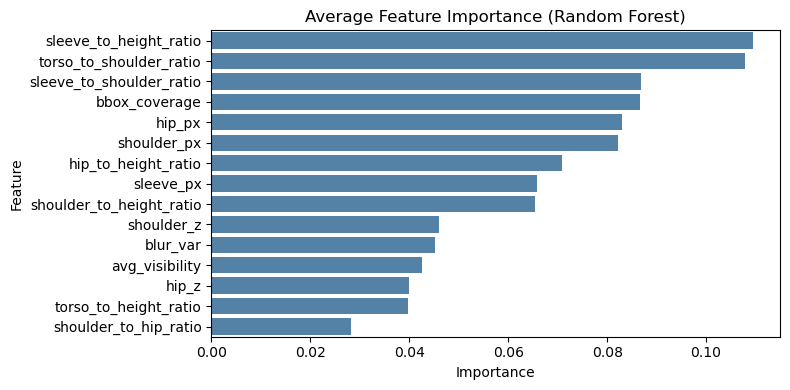

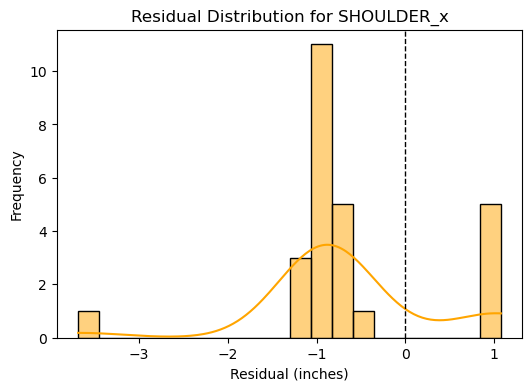

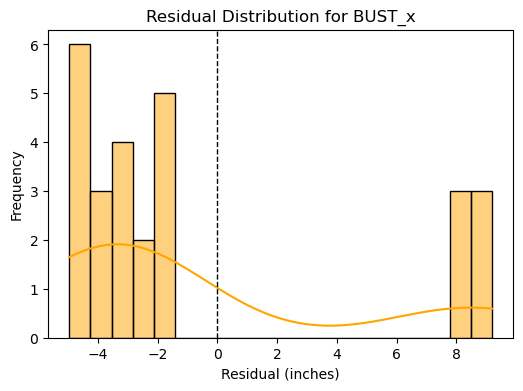

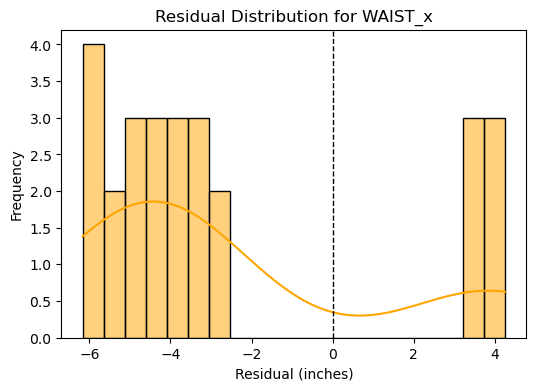

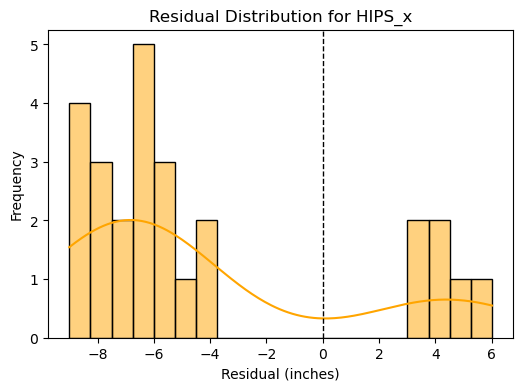

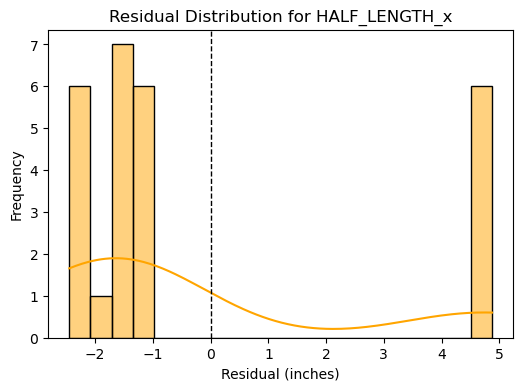

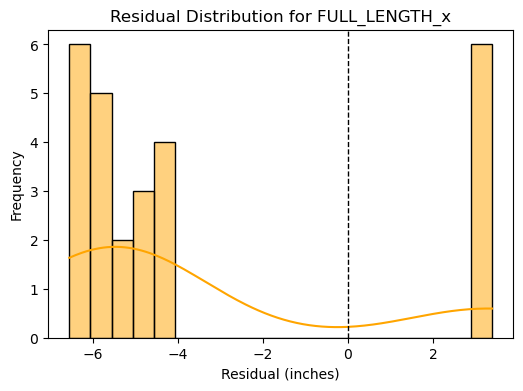

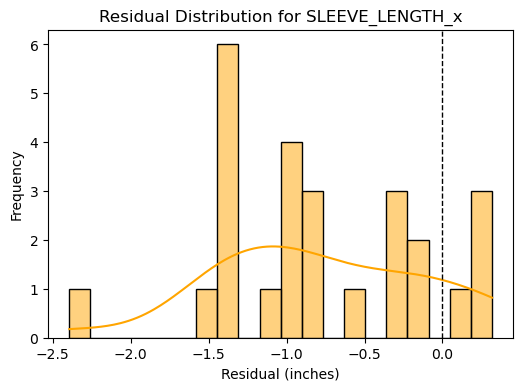

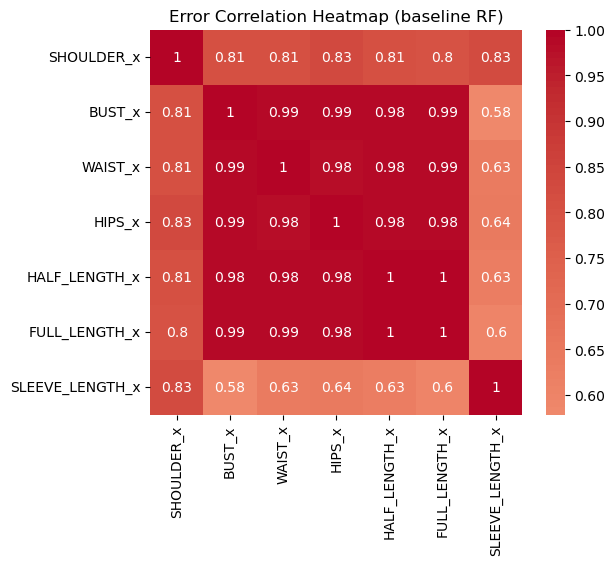


🔍 SHAP interpretability for XGBoost model...


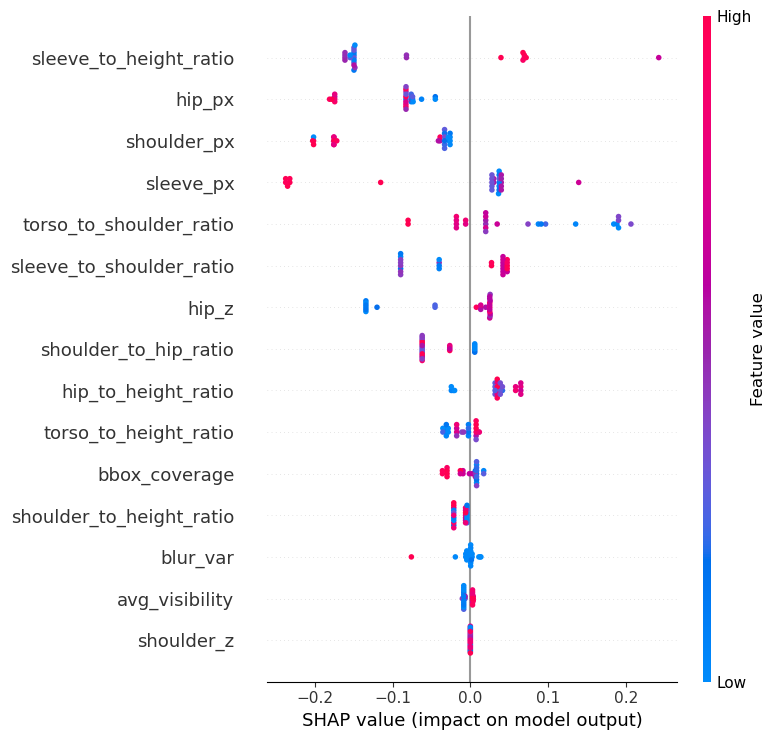

In [13]:
# ----------------------------------------------------------
# VISUALIZATION
# ----------------------------------------------------------
# 1️⃣ Per-target MAE Comparison

# Evaluate all models on validation set
mae_summary = {
    'RandomForest': rf_mae,
    'XGBoost': xgb_mae,
    'MLP': mlp_mae
}

# Create comparison DataFrame
mae_df = pd.DataFrame(mae_summary, index=TARGET_COLS)
mae_df['Mean_MAE'] = mae_df.mean(axis=1)
mae_df.loc['Average'] = mae_df.mean()
mae_df

# Visualize MAE comparison
plt.figure(figsize=(10, 5))
mae_df.loc[TARGET_COLS, ['RandomForest', 'XGBoost', 'MLP']].plot(kind='bar', ax=plt.gca())
plt.title('Model Comparison by MAE per Target')
plt.ylabel('Mean Absolute Error (inches)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# 2️⃣ Feature Importance (RF example)
if best_name == 'xgb':
    importances = np.mean([est.feature_importances_ for est in rf.estimators_], axis=0)
    fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances}).sort_values('Importance', ascending=False)
    plt.figure(figsize=(8,4))
    sns.barplot(data=fi_df, x='Importance', y='Feature', color='steelblue')
    plt.title('Average Feature Importance (Random Forest)')
    plt.tight_layout()
    plt.show()

# 3️⃣ Residual Distribution for each target
residuals = Y_test - (xgb_preds if best_name=='xgb' else rf_preds if best_name=='rf' else mlp_preds)
for i, col in enumerate(TARGET_COLS):
    plt.figure(figsize=(6,4))
    sns.histplot(residuals[:, i], bins=20, kde=True, color='orange')
    plt.axvline(0, color='black', linestyle='--', lw=1)
    plt.title(f'Residual Distribution for {col}')
    plt.xlabel('Residual (inches)')
    plt.ylabel('Frequency')
    plt.show()

#error heatmaps and target correlation
res_df = pd.DataFrame(residuals, columns=TARGET_COLS)
plt.figure(figsize=(6,5))
sns.heatmap(res_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Error Correlation Heatmap (baseline RF)")
plt.show()

# 4️⃣ SHAP Analysis (only for XGBoost)
if best_name == 'xgb':
    print("\n🔍 SHAP interpretability for XGBoost model...")
    first_target = TARGET_COLS[0]
    explainer = shap.TreeExplainer(xgb_models[first_target])
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

In [15]:
from sklearn.model_selection import GridSearchCV, learning_curve, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error

In [18]:
# ==========================================================
# 1️⃣ Define Search Spaces (Compact for Demo)
# ==========================================================

# --- RandomForest ---
rf_params = {
    'estimator__n_estimators': [100, 300, 500],
    'estimator__max_depth': [8, 12, 16],
    'estimator__min_samples_leaf': [1, 2, 4]
}

# --- MLP ---
mlp_params = {
    'estimator__hidden_layer_sizes': [(128, 64), (256,128)],
    'estimator__learning_rate_init': [0.001, 0.0005],
    'estimator__alpha': [0.0001, 0.001]
}

# --- XGBoost ---
xgb_param_grid = {
    'max_depth': [4, 6, 8],
    'eta': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# ==========================================================
# 2️⃣ RandomForest Grid Search
# ==========================================================
print("\n🔎 Hyperparameter Search: RandomForest")
rf_base = MultiOutputRegressor(RandomForestRegressor(random_state=42, n_jobs=-1))
rf_grid = GridSearchCV(
    rf_base, rf_params,
    cv=3,
    scoring=make_scorer(mean_absolute_error, greater_is_better=False),
    verbose=2, n_jobs=-1
)
rf_grid.fit(X_train, Y_train)
print("Best RF Params:", rf_grid.best_params_)
joblib.dump(rf_grid.best_estimator_, MODELS_DIR / "rf_tuned.pkl")

#===========================================================
# Xgboost_multi
#=========================================================
# print("\n🔎 Hyperparameter Search: xgb_multi")
# xgb_base = MultiOutputRegressor(xgb.XGBRegressor(objective='reg:squarederror', seed=RANDOM_STATE))
# xgb_multi_grid = GridSearchCV(
#     xgb_base, xgb_param_grid,
#     cv=3,
#     scoring=make_scorer(mean_absolute_error, greater_is_better=False),
#     verbose=2, n_jobs=-1
# )
# xgb_multi_grid.fit(X_train, Y_train)
# print("Best xgb_multi Params:", xgb_multi_grid.best_params_)
# joblib.dump(xgb_multi_grid.best_estimator_, MODELS_DIR / "xgb_multi_tuned.pkl")


# ==========================================================
# 3️⃣ XGBoost Tuning (per target)
# ==========================================================
print("\n⚙️ Hyperparameter Search: XGBoost (Per Target)")
best_xgb_models = {}
for i, target in enumerate(TARGET_COLS):
    dtrain = xgb.DMatrix(X_train, label=Y_train[:, i])
    best_rmse = float("inf")
    best_cfg = None
    best_model = None
    for md in xgb_param_grid['max_depth']:
        for eta in xgb_param_grid['eta']:
            for ss in xgb_param_grid['subsample']:
                for cs in xgb_param_grid['colsample_bytree']:
                    params = {
                        'objective': 'reg:squarederror',
                        'eval_metric': 'rmse',
                        'max_depth': md,
                        'eta': eta,
                        'subsample': ss,
                        'colsample_bytree': cs,
                        'seed': 42
                    }
                    cv_res = xgb.cv(params, dtrain, num_boost_round=300, nfold=3, early_stopping_rounds=30, verbose_eval=False)
                    mean_rmse = cv_res['test-rmse-mean'].min()
                    if mean_rmse < best_rmse:
                        best_rmse = mean_rmse
                        best_cfg = params
    print(f"{target}: Best config -> {best_cfg} (RMSE={best_rmse:.3f})")
    final_bst = xgb.train(best_cfg, dtrain, num_boost_round=300)
    best_xgb_models[target] = final_bst
    final_bst.save_model(str(MODELS_DIR / f"xgb_tuned_{target}.json"))
joblib.dump(best_xgb_models, MODELS_DIR / "xgb_tuned.pkl")


🔎 Hyperparameter Search: RandomForest
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/home/samfash/anaconda3/envs/ml_env/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/samfash/anaconda3/envs/ml_env/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/samfash/anaconda3/envs/ml_env/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from 

Best RF Params: {'estimator__max_depth': 8, 'estimator__min_samples_leaf': 1, 'estimator__n_estimators': 100}

⚙️ Hyperparameter Search: XGBoost (Per Target)
SHOULDER_x: Best config -> {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 6, 'eta': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.8, 'seed': 42} (RMSE=0.919)
BUST_x: Best config -> {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 8, 'eta': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'seed': 42} (RMSE=2.511)
WAIST_x: Best config -> {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 4, 'eta': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.8, 'seed': 42} (RMSE=2.838)
HIPS_x: Best config -> {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 6, 'eta': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'seed': 42} (RMSE=2.381)
HALF_LENGTH_x: Best config -> {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 4, 'eta': 0.05, 'subsample': 0.

['augmented_dataset/feature_cache/models/xgb_tuned.pkl']


📈 Learning Curve Diagnostics:


/home/samfash/anaconda3/envs/ml_env/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/samfash/anaconda3/envs/ml_env/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/samfash/anaconda3/envs/ml_env/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from 

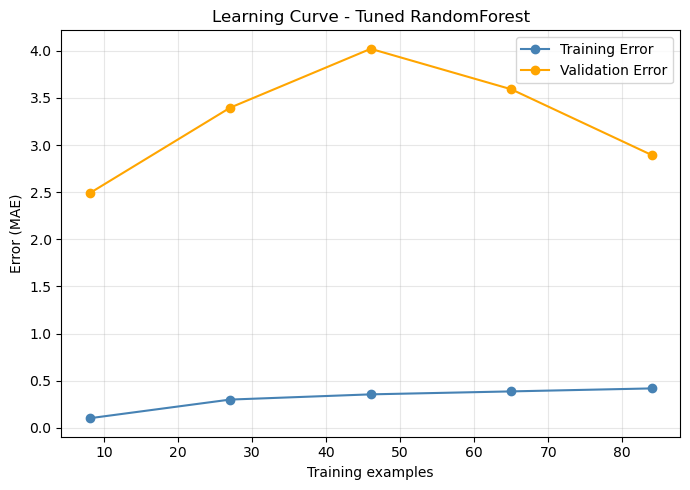


🔥 Error Heatmaps and Correlations


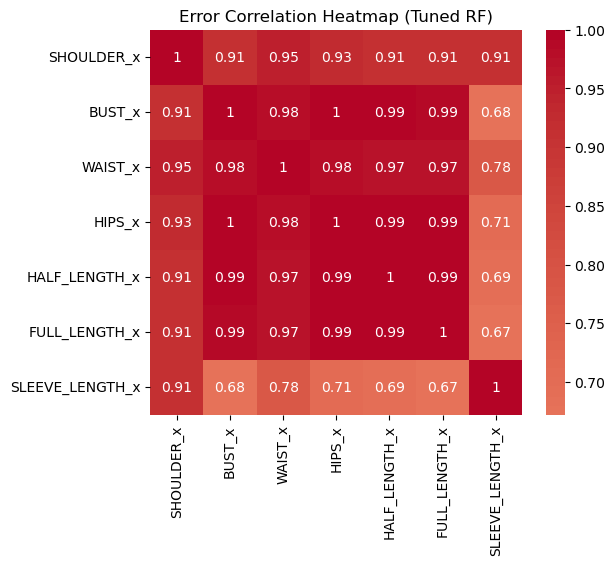

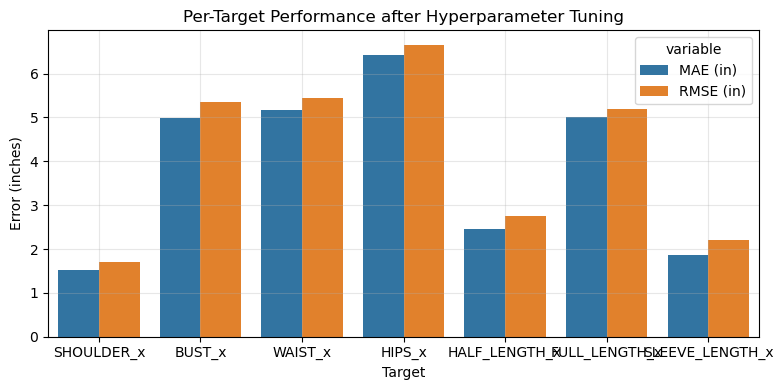

In [19]:
# ==========================================================
# 4️⃣ Learning Curves (for bias-variance tradeoff)
# ==========================================================
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=3, scoring='neg_mean_absolute_error'):
    plt.figure(figsize=(7,5))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Error (MAE)")
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
    )
    train_scores_mean = -np.mean(train_scores, axis=1)
    val_scores_mean = -np.mean(val_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', color="steelblue", label="Training Error")
    plt.plot(train_sizes, val_scores_mean, 'o-', color="orange", label="Validation Error")
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n📈 Learning Curve Diagnostics:")
rf_best = rf_grid.best_estimator_
plot_learning_curve(rf_best, "Learning Curve - Tuned RandomForest", X_train, Y_train)

# ==========================================================
# 5️⃣ Error Heatmaps & Target Correlation
# ==========================================================
print("\n🔥 Error Heatmaps and Correlations")

best_rf_preds = rf_best.predict(X_test)
residuals = Y_test - best_rf_preds

res_df = pd.DataFrame(residuals, columns=TARGET_COLS)
plt.figure(figsize=(6,5))
sns.heatmap(res_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Error Correlation Heatmap (Tuned RF)")
plt.show()

# ==========================================================
# 6️⃣ Per-Target Performance Visualization
# ==========================================================
mae_per_target = [mean_absolute_error(Y_test[:, i], best_rf_preds[:, i]) for i in range(Y_test.shape[1])]
rmse_per_target = [np.sqrt(mean_squared_error(Y_test[:, i], best_rf_preds[:, i])) for i in range(Y_test.shape[1])]

perf_df = pd.DataFrame({
    'Target': TARGET_COLS,
    'MAE (in)': mae_per_target,
    'RMSE (in)': rmse_per_target
})

plt.figure(figsize=(8,4))
sns.barplot(data=perf_df.melt(id_vars='Target'), x='Target', y='value', hue='variable')
plt.title("Per-Target Performance after Hyperparameter Tuning")
plt.ylabel("Error (inches)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# -------------------------
# 2. Optuna Hyperparameter Tuning
# -------------------------
import optuna
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Reuse preprocessed X_train, Y_train
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "n_jobs": -1,
        "random_state": RANDOM_STATE
    }
    model = MultiOutputRegressor(RandomForestRegressor(**params))
    scores = -1 * cross_val_score(model, X_train, Y_train, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
    return np.mean(scores)

def objective_xgb(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "lambda": trial.suggest_float("lambda", 0.1, 10, log=True),
        "alpha": trial.suggest_float("alpha", 0.0, 1.0),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "seed": RANDOM_STATE
    }
    model = MultiOutputRegressor(xgb.XGBRegressor(**params))
    scores = -1 * cross_val_score(model, X_train, Y_train, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
    return np.mean(scores)

# Run searches
study_rf = optuna.create_study(direction="minimize", study_name="RF_tuning")
study_rf.optimize(objective_rf, n_trials=25, show_progress_bar=True)

study_xgb = optuna.create_study(direction="minimize", study_name="XGB_tuning")
study_xgb.optimize(objective_xgb, n_trials=25, show_progress_bar=True)

print("Best RF params:", study_rf.best_params)
print("Best XGB params:", study_xgb.best_params)

[I 2025-11-13 21:52:19,420] A new study created in memory with name: RF_tuning


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-11-13 21:52:25,827] Trial 0 finished with value: 1.5115162697155444 and parameters: {'n_estimators': 489, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 1.5115162697155444.
[I 2025-11-13 21:52:33,368] Trial 1 finished with value: 1.5110018631580704 and parameters: {'n_estimators': 583, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 1.5110018631580704.
[I 2025-11-13 21:52:39,616] Trial 2 finished with value: 1.6480732469100448 and parameters: {'n_estimators': 464, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 1.5110018631580704.
[I 2025-11-13 21:52:49,076] Trial 3 finished with value: 1.6864510561169823 and parameters: {'n_estimators': 633, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 1.51100186315807

[I 2025-11-13 21:54:45,132] A new study created in memory with name: XGB_tuning


[I 2025-11-13 21:54:45,130] Trial 24 finished with value: 1.4076498347741868 and parameters: {'n_estimators': 429, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 11 with value: 1.3094401748187376.


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-11-13 21:54:46,934] Trial 0 finished with value: 1.1220033764116233 and parameters: {'learning_rate': 0.011969341588760805, 'max_depth': 6, 'subsample': 0.7845122280329501, 'colsample_bytree': 0.8577798541363948, 'lambda': 6.453685446203946, 'alpha': 0.22092434697744578, 'n_estimators': 430}. Best is trial 0 with value: 1.1220033764116233.
[I 2025-11-13 21:54:47,824] Trial 1 finished with value: 1.4747992072346554 and parameters: {'learning_rate': 0.010057086291888838, 'max_depth': 3, 'subsample': 0.6096296608368562, 'colsample_bytree': 0.986459682552935, 'lambda': 5.886434349052843, 'alpha': 0.6534338323567368, 'n_estimators': 288}. Best is trial 0 with value: 1.1220033764116233.
[I 2025-11-13 21:54:48,775] Trial 2 finished with value: 1.1479665428778796 and parameters: {'learning_rate': 0.027295267124318037, 'max_depth': 7, 'subsample': 0.8951617490817321, 'colsample_bytree': 0.8242222804428488, 'lambda': 0.5216850672302504, 'alpha': 0.5194724266141941, 'n_estimators': 172}. 

In [21]:
# -------------------------
# 8. Inference helper
# -------------------------

# %%
# Loads saved transformers & model and predicts from a single image file.

def infer_from_image(image_path, user_id=None, image_filename=None):
    # extract landmarks & features
    imp = joblib.load(MODELS_DIR / 'imputer.pkl')
    scaler = joblib.load(MODELS_DIR / 'scaler.pkl')
    feature_cols = joblib.load(MODELS_DIR / 'feature_cols.pkl')
    
    kps = extract_landmarks_for_image(image_path)
    feats = compute_features_from_landmarks_and_image(kps['kps'], kps['img_h'], kps['img_w'], kps['image'])
    if feats is None:
        return None
    # build row vector
    row = [feats.get(c, np.nan) for c in feature_cols]
    row = np.array(row).reshape(1,-1)
    row = imp.transform(row)
    row = scaler.transform(row)
    # load best model
    best = joblib.load(MODELS_DIR / 'best_models.pkl')
    if best_name == 'xgb':
        preds = {t: float(best[t].predict(xgb.DMatrix(row))[0]) for t in TARGET_COLS}
    else:
        preds_array = best.predict(row)
        preds = {t: float(preds_array[0,i]) for i,t in enumerate(TARGET_COLS)}

    return preds


In [22]:
# Save a small inference demo CSV with one row from test
if len(test_df) > 0:
    demo = test_df.iloc[19:20]
    demo.to_csv(OUTPUT_DIR / 'demo_row.csv', index=False)
    print('Saved demo_row.csv')

single_d = pd.read_csv(OUTPUT_DIR / 'demo_row.csv')
single_d.head()

Saved demo_row.csv


,USERID,IMAGES,GENDER_x,SHOULDER_x,BUST_x,WAIST_x,HIPS_x,HALF_LENGTH_x,FULL_LENGTH_x,SLEEVE_LENGTH_x,...,shoulder_to_height_ratio,hip_to_height_ratio,sleeve_to_height_ratio,sleeve_to_shoulder_ratio,torso_to_height_ratio,torso_to_shoulder_ratio,low_visibility_flag,low_coverage_flag,blurry_flag,data_quality
0,linda,linda_aug0.jpg,female,14.0,33.5,27.0,34.5,14.0,52,21.5,...,0.279736,0.129935,0.276888,0.989819,0.40497,1.447686,0,0,0,ok


In [23]:
import os

In [24]:
ima_p = single_d["IMAGES"].values[0]
imgpath = os.path.join(IMAGE_DIR, ima_p)
single_pred = infer_from_image(imgpath)
single_pred

{'SHOULDER_x': 14.903898239135742,
 'BUST_x': 35.28768539428711,
 'WAIST_x': 29.70247459411621,
 'HIPS_x': 40.41061019897461,
 'HALF_LENGTH_x': 15.609614372253418,
 'FULL_LENGTH_x': 56.75050354003906,
 'SLEEVE_LENGTH_x': 22.625667572021484}